선택 기준
- 최신 날짜: 20260318
- 최신 시각: 182225

선택 파일 목록
 channel                                                                       filename
       1 In_agsmotor_green_UUID_000003_ch1_20260318_182225.csv
       2 In_agsmotor_green_UUID_000003_ch2_20260318_182225.csv
       3 In_agsmotor_green_UUID_000003_ch3_20260318_182225.csv
       4 In_agsmotor_green_UUID_000003_ch4_20260318_182225.csv
       5 In_agsmotor_green_UUID_000003_ch5_20260318_182225.csv
       6 In_agsmotor_green_UUID_000003_ch6_20260318_182225.csv
       7 In_agsmotor_green_UUID_000003_ch7_20260318_182225.csv
       8 In_agsmotor_green_UUID_000003_ch8_20260318_182225.csv

데이터 개요
- 총 행 수: 370,216
- open_rate 최소/최대: 0.00 / 100.00
- open_rate 평균/중앙값: 10.89 / 0.00

open_rate 전체 분포 통계


,open_rate
count,370216.000000
mean,10.886842
std,27.264028
min,0.000000
1%,0.000000
5%,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
95%,95.000000



채널별 open_rate 분포 통계


,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
1,46277.0,11.815891,23.723180,0.0,0.0,0.0,0.0,100.0
2,46277.0,7.779199,18.370592,0.0,0.0,0.0,0.0,100.0
3,46277.0,11.875100,27.381492,0.0,0.0,0.0,0.0,100.0
4,46277.0,14.796011,28.958352,0.0,0.0,0.0,0.0,98.0
5,46277.0,0.367223,2.763464,0.0,0.0,0.0,0.0,50.0
6,46277.0,0.158783,2.745529,0.0,0.0,0.0,0.0,50.0
7,46277.0,20.151263,38.850707,0.0,0.0,0.0,0.0,98.0
8,46277.0,20.151263,38.850707,0.0,0.0,0.0,0.0,98.0



IQR 이상치 기준
- 하한/상한: 0.00 / 0.00
- 이상치 개수: 68,801 (18.58%)


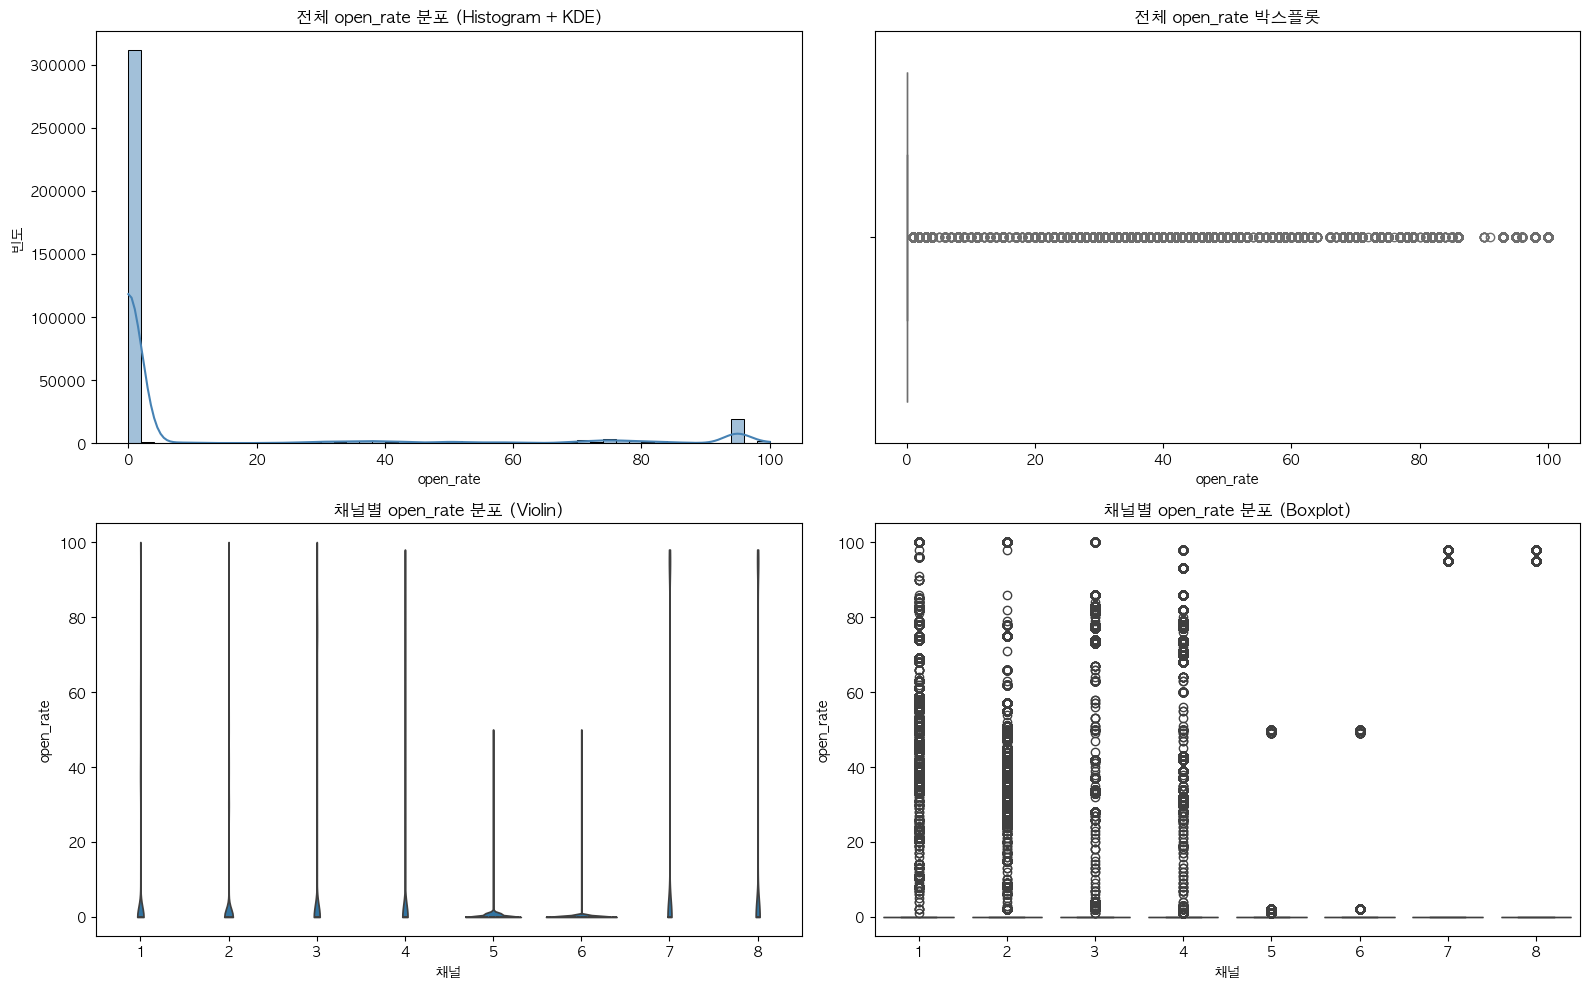


개폐율 구간 비율(%)


,ratio_%
open_rate_bin,
<0,81.415984
0-10,3.279167
10-30,1.072887
30-70,5.002215
70-90,3.389913
90-100,5.839834
>100,0.000000


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

base_dir = Path('/Users/jeong-won-il/workspace/SDF/train/pipeline_output/organized_by_sensor/AGS_Green_7동_모터제어')

# 파일명 예시:
# In_agsmotor_green_<sensor_id>_ch1_20260318_182225.csv
pattern = re.compile(r'.*_ch(?P<ch>\d+)_(?P<date>\d{8})_(?P<time>\d{6})\.csv$')

rows = []
for p in base_dir.glob('*.csv'):
    m = pattern.match(p.name)
    if not m:
        continue
    rows.append({
        'path': p,
        'filename': p.name,
        'channel': int(m.group('ch')),
        'file_date': m.group('date'),
        'file_time': m.group('time'),
        'dt_key': pd.to_datetime(m.group('date') + m.group('time'), format='%Y%m%d%H%M%S')
    })

files_df = pd.DataFrame(rows)
if files_df.empty:
    raise ValueError(f'CSV 파일을 찾지 못했습니다: {base_dir}')

# 1) 같은 날짜 중 "최신 날짜" 선택
latest_date = files_df['file_date'].max()
df_latest_date = files_df[files_df['file_date'] == latest_date].copy()

# 2) 해당 날짜에서 "최신 수집시각" 선택
latest_time = df_latest_date['file_time'].max()
df_latest_time = df_latest_date[df_latest_date['file_time'] == latest_time].copy()

# 3) 최신 시각 파일 중 채널 기준 8개 선택 (ch1~ch8 기대)
selected_files = df_latest_time.sort_values('channel').head(8).copy()

if len(selected_files) < 8:
    print(f'경고: 선택된 파일 수가 8개보다 적습니다. 현재 {len(selected_files)}개')

print('선택 기준')
print(f'- 최신 날짜: {latest_date}')
print(f'- 최신 시각: {latest_time}')
print('\n선택 파일 목록')
print(selected_files[['channel', 'filename']].to_string(index=False))

# 파일 로드 및 open_rate 병합
data_parts = []
for _, r in selected_files.iterrows():
    df = pd.read_csv(r['path'])
    if 'open_rate' not in df.columns:
        print(f"open_rate 컬럼 없음: {r['filename']}")
        continue

    df['channel'] = r['channel']
    df['source_file'] = r['filename']
    df['ts'] = pd.to_datetime(df['ts'], format='mixed', utc=True, errors='coerce')
    df['open_rate'] = pd.to_numeric(df['open_rate'], errors='coerce')
    data_parts.append(df[['ts', 'channel', 'open_rate', 'source_file']])

if not data_parts:
    raise ValueError('분석 가능한 open_rate 데이터가 없습니다.')

all_data = pd.concat(data_parts, ignore_index=True)
all_data = all_data.dropna(subset=['open_rate'])

if all_data.empty:
    raise ValueError('open_rate 유효값이 없습니다.')

print('\n데이터 개요')
print(f'- 총 행 수: {len(all_data):,}')
print(f"- open_rate 최소/최대: {all_data['open_rate'].min():.2f} / {all_data['open_rate'].max():.2f}")
print(f"- open_rate 평균/중앙값: {all_data['open_rate'].mean():.2f} / {all_data['open_rate'].median():.2f}")

# 전체 분포 통계
summary = all_data['open_rate'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print('\nopen_rate 전체 분포 통계')
display(summary.to_frame(name='open_rate'))

# 채널별 분포 통계
ch_summary = all_data.groupby('channel')['open_rate'].describe()
print('\n채널별 open_rate 분포 통계')
display(ch_summary)

# 이상치(IQR) 참고
q1 = all_data['open_rate'].quantile(0.25)
q3 = all_data['open_rate'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_mask = (all_data['open_rate'] < lower) | (all_data['open_rate'] > upper)
outlier_rate = outlier_mask.mean() * 100

print('\nIQR 이상치 기준')
print(f'- 하한/상한: {lower:.2f} / {upper:.2f}')
print(f'- 이상치 개수: {outlier_mask.sum():,} ({outlier_rate:.2f}%)')

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) 전체 히스토그램 + KDE
sns.histplot(all_data['open_rate'], bins=50, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('전체 open_rate 분포 (Histogram + KDE)')
axes[0, 0].set_xlabel('open_rate')
axes[0, 0].set_ylabel('빈도')

# 2) 전체 박스플롯
sns.boxplot(x=all_data['open_rate'], ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('전체 open_rate 박스플롯')
axes[0, 1].set_xlabel('open_rate')

# 3) 채널별 바이올린플롯
sns.violinplot(data=all_data, x='channel', y='open_rate', ax=axes[1, 0], inner='quartile', cut=0)
axes[1, 0].set_title('채널별 open_rate 분포 (Violin)')
axes[1, 0].set_xlabel('채널')
axes[1, 0].set_ylabel('open_rate')

# 4) 채널별 박스플롯
sns.boxplot(data=all_data, x='channel', y='open_rate', ax=axes[1, 1])
axes[1, 1].set_title('채널별 open_rate 분포 (Boxplot)')
axes[1, 1].set_xlabel('채널')
axes[1, 1].set_ylabel('open_rate')

plt.tight_layout()
plt.show()

# 개폐율 구간 비율(참고)
bins = [-np.inf, 0, 10, 30, 70, 90, 100, np.inf]
labels = ['<0', '0-10', '10-30', '30-70', '70-90', '90-100', '>100']
all_data['open_rate_bin'] = pd.cut(all_data['open_rate'], bins=bins, labels=labels)

bin_ratio = all_data['open_rate_bin'].value_counts(normalize=True).sort_index() * 100
print('\n개폐율 구간 비율(%)')
display(bin_ratio.to_frame(name='ratio_%'))

활성 판정 기준: open_rate > 0
전체 구간 수: 239

채널별 활성/비활성 시간(분) 요약


is_active,inactive_min,active_min,active_ratio_%
channel,,,
1,31642.088417,9818.780267,23.682042
2,33594.881917,7875.530817,18.990722
3,34158.265733,7311.930133,17.631771
4,31738.515317,9730.082300,23.463736
5,29621.409833,12134.233100,29.060104
6,41508.918583,245.926500,0.588977
7,29734.512883,12022.723367,28.791952
8,29734.512883,12022.723367,28.791952


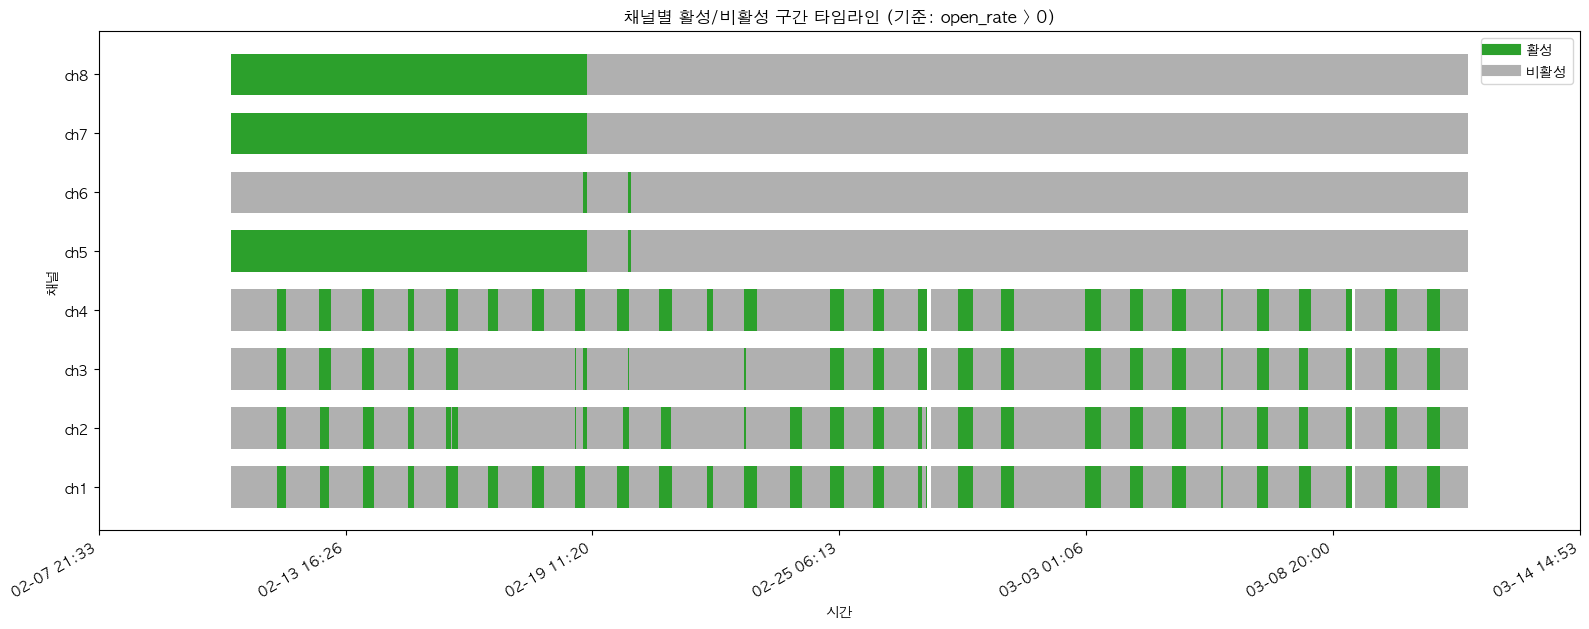

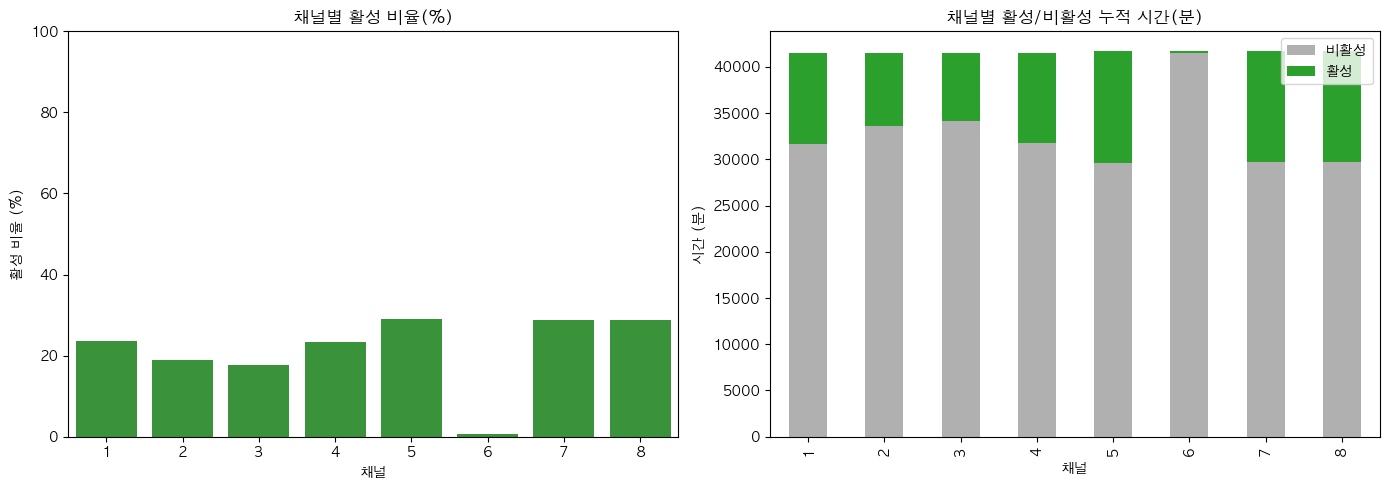


구간 데이터 샘플


,channel,is_active,start,end,n_points,duration_min
0,1,False,2026-02-11 00:00:46.321000+00:00,2026-02-12 01:52:34.438000+00:00,1328,1551.801950
1,1,True,2026-02-12 01:53:37.088000+00:00,2026-02-12 06:43:30.324000+00:00,251,289.887267
2,1,False,2026-02-12 06:44:32.975000+00:00,2026-02-13 02:09:18.361000+00:00,906,1164.756433
3,1,True,2026-02-13 02:10:20.302000+00:00,2026-02-13 06:54:47.471000+00:00,184,284.452817
4,1,False,2026-02-13 06:55:50.122000+00:00,2026-02-14 02:16:51.315000+00:00,880,1161.019883
5,1,True,2026-02-14 02:17:53.966000+00:00,2026-02-14 08:12:27.541000+00:00,291,354.559583
6,1,False,2026-02-14 08:13:30.190000+00:00,2026-02-15 03:29:19.116000+00:00,917,1155.815433
7,1,True,2026-02-15 03:32:27.062000+00:00,2026-02-15 07:09:00.026000+00:00,187,216.549400
8,1,False,2026-02-15 07:11:05.321000+00:00,2026-02-16 01:01:15.253000+00:00,915,1070.165533
9,1,True,2026-02-16 01:02:17.904000+00:00,2026-02-16 03:54:51.306000+00:00,144,172.556700


In [2]:
# 채널별 비활성/활성 구간 시각화
# 기준: open_rate > active_threshold 이면 활성, 그 외 비활성

active_threshold = 0  # 필요 시 조정 (예: 5, 10)

state_df = all_data[['ts', 'channel', 'open_rate']].copy()
state_df = state_df.dropna(subset=['ts', 'open_rate'])
state_df = state_df.sort_values(['channel', 'ts']).reset_index(drop=True)
state_df['is_active'] = state_df['open_rate'] > active_threshold

# 연속 구간(start~end) 생성 함수
def build_intervals(df_ch):
    df_ch = df_ch.sort_values('ts').copy()
    if df_ch.empty:
        return pd.DataFrame(columns=['channel', 'is_active', 'start', 'end', 'duration_min'])

    # 상태가 바뀔 때마다 그룹 번호 증가
    state_change = df_ch['is_active'].ne(df_ch['is_active'].shift()).cumsum()

    intervals = (
        df_ch.groupby(state_change)
        .agg(
            channel=('channel', 'first'),
            is_active=('is_active', 'first'),
            start=('ts', 'min'),
            end=('ts', 'max'),
            n_points=('ts', 'size')
        )
        .reset_index(drop=True)
    )

    # duration이 0으로 보이는 문제를 줄이기 위해 마지막 점도 포함한 근사 길이 계산
    # (다음 시점이 있으면 그 차이를 더하는 방식 대신, 단순히 end-start를 사용)
    intervals['duration_min'] = (intervals['end'] - intervals['start']).dt.total_seconds() / 60

    return intervals

interval_parts = []
for ch, g in state_df.groupby('channel'):
    interval_parts.append(build_intervals(g))

interval_df = pd.concat(interval_parts, ignore_index=True) if interval_parts else pd.DataFrame()

if interval_df.empty:
    raise ValueError('활성/비활성 구간을 생성할 데이터가 없습니다.')

print(f'활성 판정 기준: open_rate > {active_threshold}')
print(f'전체 구간 수: {len(interval_df):,}')

summary_by_ch = (
    interval_df.groupby(['channel', 'is_active'])['duration_min']
    .sum()
    .unstack(fill_value=0)
    .rename(columns={False: 'inactive_min', True: 'active_min'})
)
summary_by_ch['active_ratio_%'] = (
    summary_by_ch['active_min'] / (summary_by_ch['active_min'] + summary_by_ch['inactive_min']).replace(0, np.nan) * 100
)

print('\n채널별 활성/비활성 시간(분) 요약')
display(summary_by_ch)

# 1) 타임라인(구간) 시각화
channels = sorted(interval_df['channel'].unique())
fig, ax = plt.subplots(figsize=(16, max(5, len(channels) * 0.8)))

color_map = {True: '#2ca02c', False: '#b0b0b0'}  # 활성: 초록, 비활성: 회색
label_map = {True: '활성', False: '비활성'}

for i, ch in enumerate(channels):
    ch_intervals = interval_df[interval_df['channel'] == ch]
    for _, row in ch_intervals.iterrows():
        start_num = row['start'].to_pydatetime().timestamp()
        end_num = row['end'].to_pydatetime().timestamp()
        width = max(end_num - start_num, 1)  # 너무 짧은 구간도 보이도록 최소폭 1초
        ax.broken_barh([(start_num, width)], (i - 0.35, 0.7), facecolors=color_map[row['is_active']])

ax.set_yticks(range(len(channels)))
ax.set_yticklabels([f'ch{ch}' for ch in channels])
ax.set_title(f'채널별 활성/비활성 구간 타임라인 (기준: open_rate > {active_threshold})')
ax.set_xlabel('시간')
ax.set_ylabel('채널')

# x축 timestamp -> datetime 라벨
xticks = ax.get_xticks()
xticklabels = [pd.to_datetime(x, unit='s', utc=True).tz_convert(None).strftime('%m-%d %H:%M') if np.isfinite(x) else '' for x in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=30, ha='right')

legend_handles = [
    plt.Line2D([0], [0], color=color_map[True], lw=8, label=label_map[True]),
    plt.Line2D([0], [0], color=color_map[False], lw=8, label=label_map[False])
]
ax.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

# 2) 채널별 활성 비율 시각화
ratio_plot = summary_by_ch.reset_index().copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=ratio_plot, x='channel', y='active_ratio_%', ax=axes[0], color='#2ca02c')
axes[0].set_title('채널별 활성 비율(%)')
axes[0].set_xlabel('채널')
axes[0].set_ylabel('활성 비율 (%)')
axes[0].set_ylim(0, 100)

stack_df = ratio_plot[['channel', 'inactive_min', 'active_min']].set_index('channel')
stack_df.plot(kind='bar', stacked=True, ax=axes[1], color=['#b0b0b0', '#2ca02c'])
axes[1].set_title('채널별 활성/비활성 누적 시간(분)')
axes[1].set_xlabel('채널')
axes[1].set_ylabel('시간 (분)')
axes[1].legend(['비활성', '활성'])

plt.tight_layout()
plt.show()

# 구간 테이블(앞부분 확인)
print('\n구간 데이터 샘플')
display(interval_df.head(20))

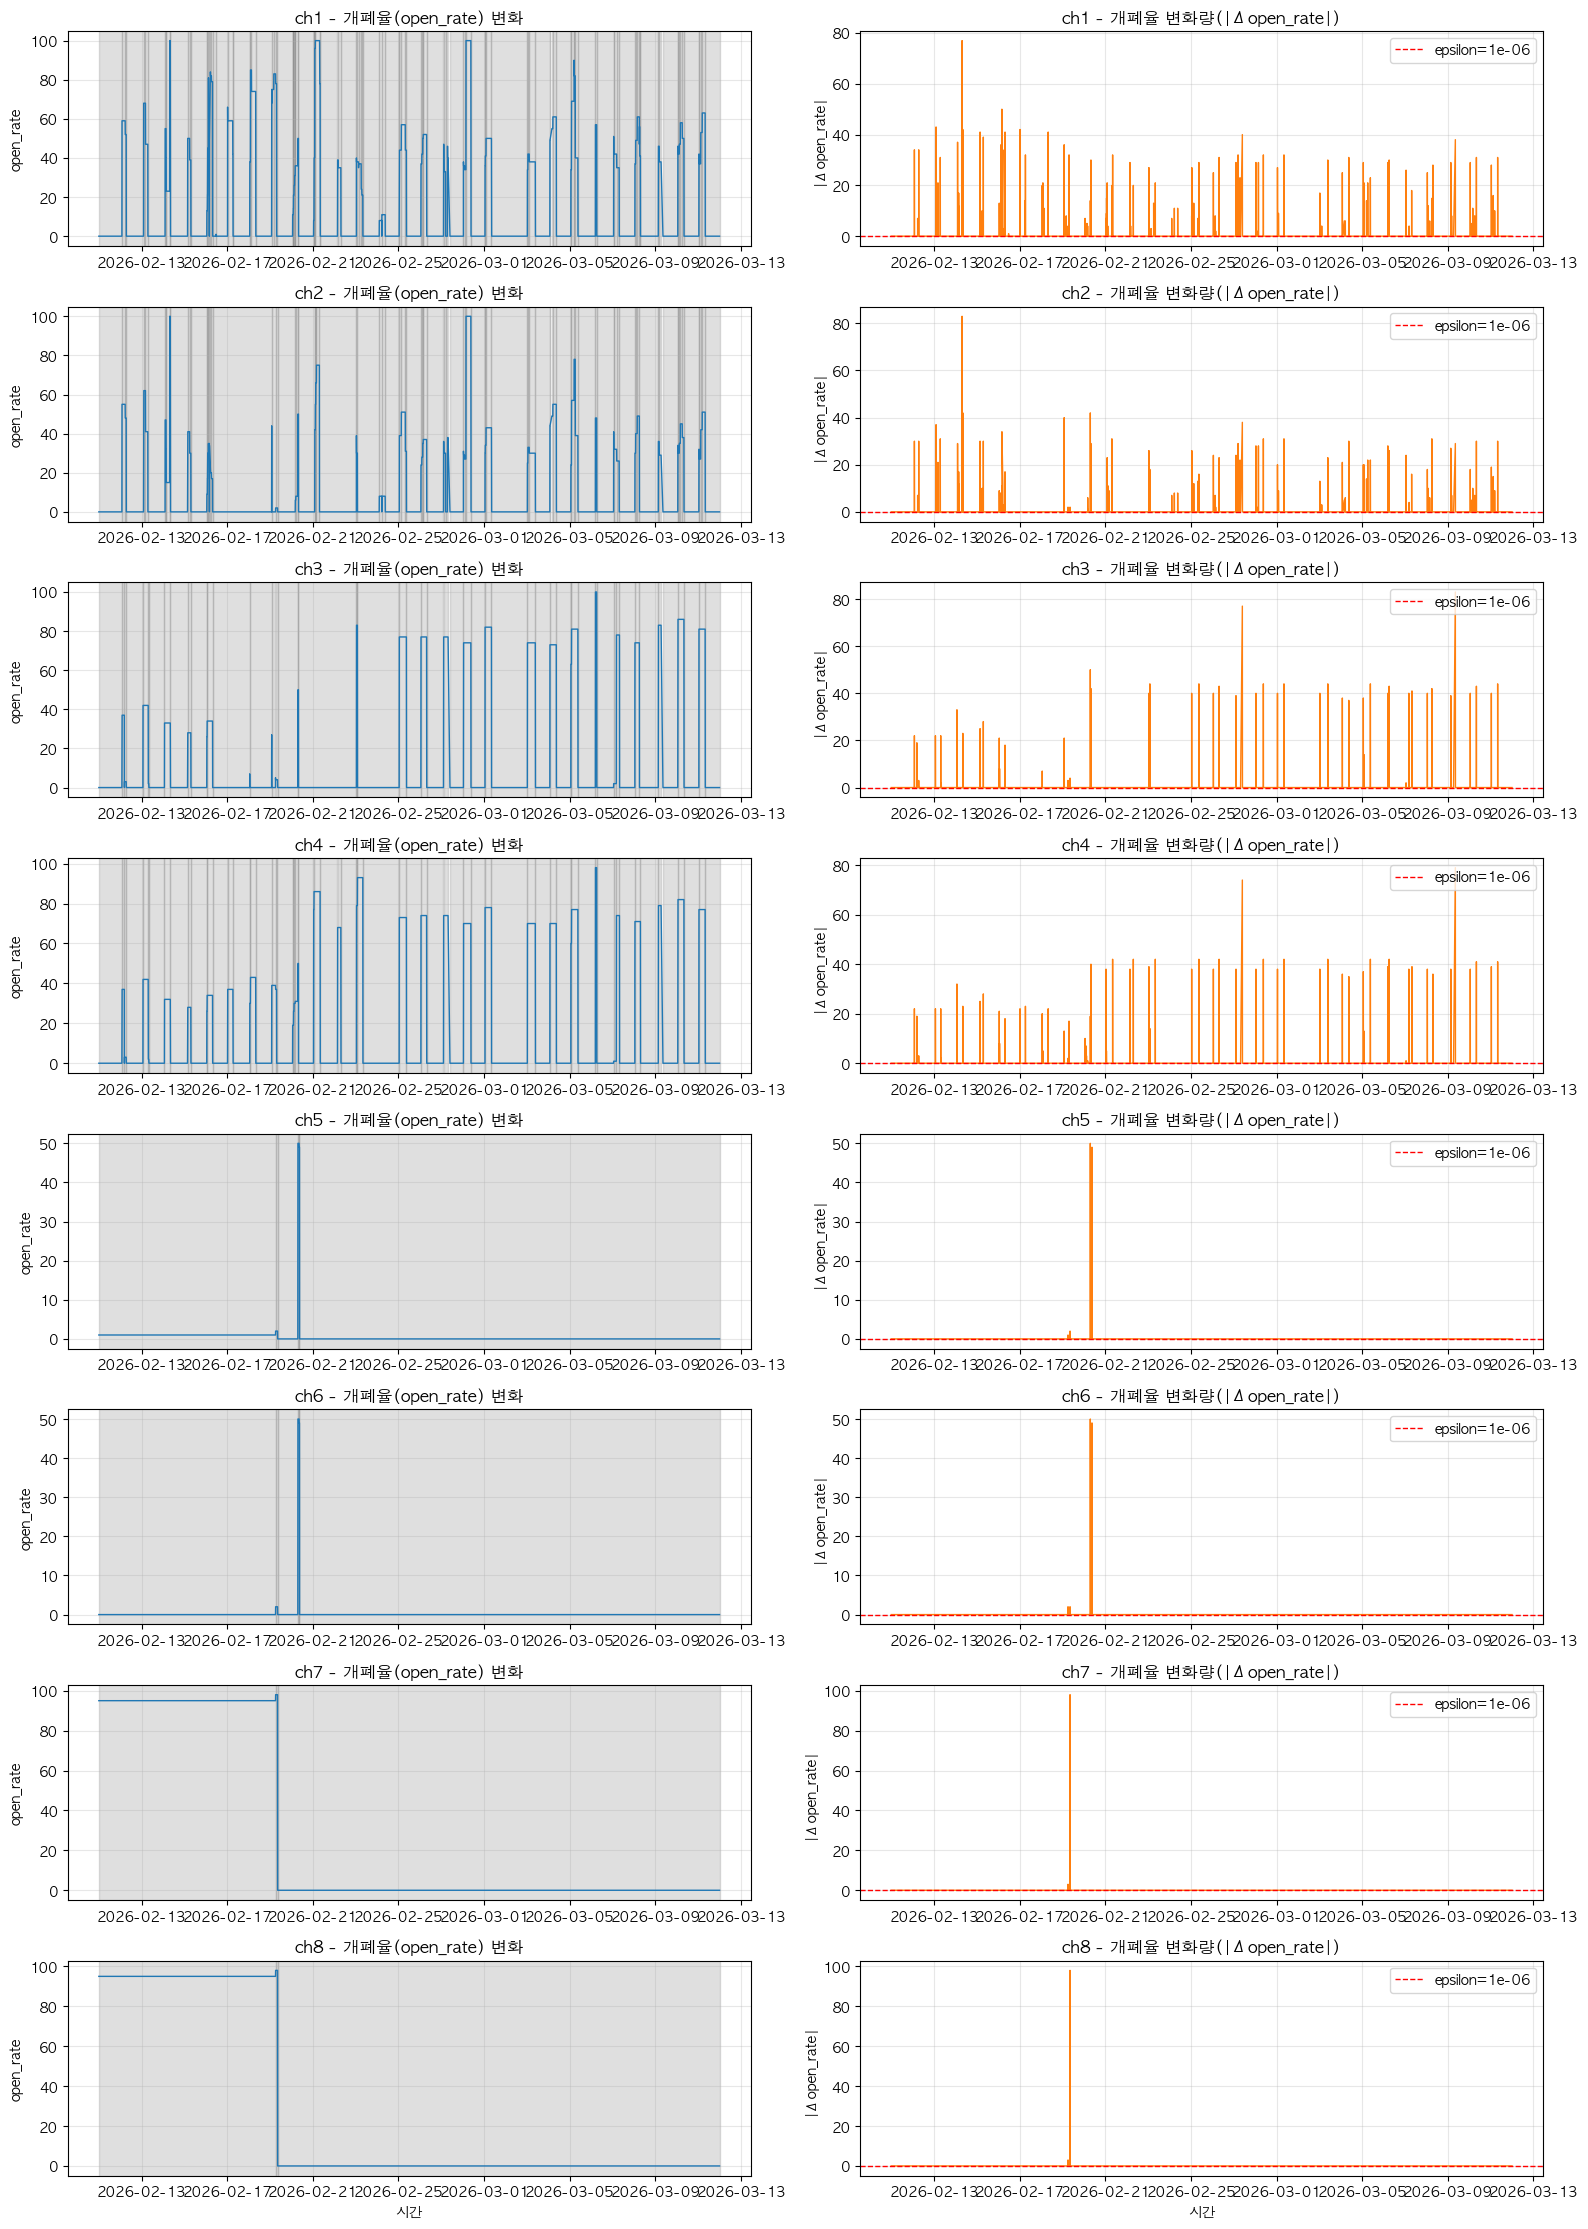

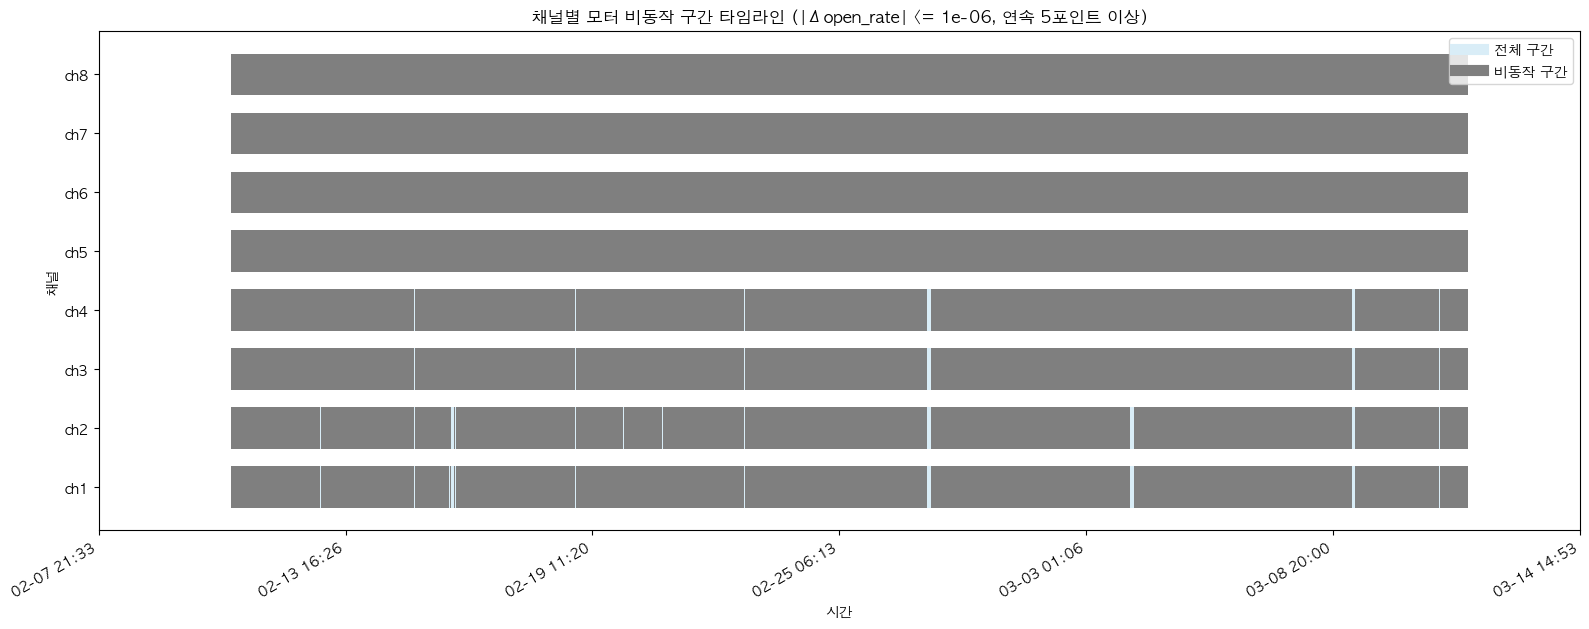

채널별 비동작 구간 요약 (비율 포함)


,still_intervals,total_still_min,avg_still_min,max_still_min,total_duration_min,still_ratio_%
channel,,,,,,
1,128,40952.904933,319.944570,2411.003117,41758.824917,98.070061
2,101,41047.031183,406.406249,3971.413100,41758.824917,98.295465
3,53,41348.214183,780.154985,3896.764650,41758.824917,99.016709
4,67,41306.887600,616.520710,2442.580133,41758.824917,98.917744
5,6,41750.088200,6958.348033,28258.070533,41758.824917,99.979078
6,6,41750.088200,6958.348033,28258.070533,41758.824917,99.979078
7,3,41754.867900,13918.289300,29733.727950,41758.824917,99.990524
8,3,41754.867900,13918.289300,29733.727950,41758.824917,99.990524


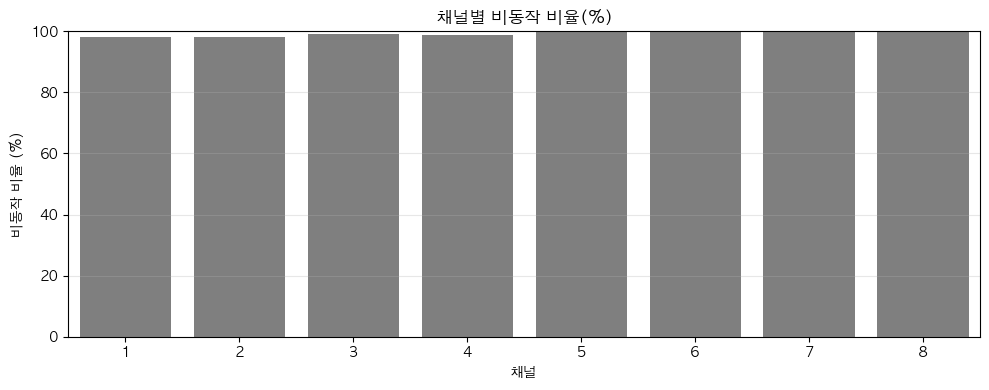

비동작 구간 상세(상위 30개)


,channel,start,end,n_points,duration_min
0,1,2026-02-11 00:00:46.321000+00:00,2026-02-12 01:52:34.438000+00:00,1328,1551.801950
1,1,2026-02-12 01:56:45.037000+00:00,2026-02-12 05:31:14.765000+00:00,190,214.495467
2,1,2026-02-12 05:33:20.065000+00:00,2026-02-12 06:42:27.673000+00:00,57,69.126800
3,1,2026-02-12 06:45:35.626000+00:00,2026-02-13 02:09:18.361000+00:00,905,1163.712250
4,1,2026-02-13 02:19:44.265000+00:00,2026-02-13 04:18:24.107000+00:00,98,118.664033
5,1,2026-02-13 04:20:29.407000+00:00,2026-02-13 06:53:44.824000+00:00,75,153.256950
6,1,2026-02-13 06:56:52.870000+00:00,2026-02-14 02:16:51.315000+00:00,879,1159.974083
7,1,2026-02-14 02:19:59.268000+00:00,2026-02-14 03:20:44.329000+00:00,37,60.751017
8,1,2026-02-14 03:25:57.572000+00:00,2026-02-14 03:31:10.814000+00:00,5,5.220700
9,1,2026-02-14 03:34:18.761000+00:00,2026-02-14 07:20:14.207000+00:00,198,225.924100


In [4]:
# 채널별 개폐율 변화 + 모터 비동작(변화 없음) 구간 시각화

# --- 파라미터 ---
change_epsilon = 1e-6   # 이 값 이하 변화는 '변화 없음'으로 간주
min_still_points = 5    # 연속 n개 이상 변화 없음이면 비동작 구간으로 표시

viz_df = all_data[['ts', 'channel', 'open_rate']].copy()
viz_df = viz_df.dropna(subset=['ts', 'open_rate']).sort_values(['channel', 'ts']).reset_index(drop=True)

# 채널별 변화량 계산
viz_df['delta_open_rate'] = viz_df.groupby('channel')['open_rate'].diff().abs()
viz_df['is_still'] = viz_df['delta_open_rate'].fillna(0) <= change_epsilon

# 연속 비동작 구간 추출 함수
def extract_still_intervals(df_ch, min_points=5):
    df_ch = df_ch.sort_values('ts').copy()
    if df_ch.empty:
        return pd.DataFrame(columns=['channel', 'start', 'end', 'n_points', 'duration_min'])

    # 상태 변화 시 그룹 분리
    grp = df_ch['is_still'].ne(df_ch['is_still'].shift()).cumsum()
    grouped = (
        df_ch.groupby(grp)
        .agg(
            channel=('channel', 'first'),
            is_still=('is_still', 'first'),
            start=('ts', 'min'),
            end=('ts', 'max'),
            n_points=('ts', 'size')
        )
        .reset_index(drop=True)
    )

    still_only = grouped[(grouped['is_still']) & (grouped['n_points'] >= min_points)].copy()
    still_only['duration_min'] = (still_only['end'] - still_only['start']).dt.total_seconds() / 60
    return still_only[['channel', 'start', 'end', 'n_points', 'duration_min']]

still_parts = []
for ch, g in viz_df.groupby('channel'):
    still_parts.append(extract_still_intervals(g, min_points=min_still_points))

still_df = pd.concat(still_parts, ignore_index=True) if still_parts else pd.DataFrame(
    columns=['channel', 'start', 'end', 'n_points', 'duration_min']
)

# --- 1) 채널별 개폐율 변화 시각화 (시계열 + 변화량) ---
channels = sorted(viz_df['channel'].unique())
fig, axes = plt.subplots(len(channels), 2, figsize=(16, max(4, len(channels) * 2.8)), sharex=False)

if len(channels) == 1:
    axes = np.array([axes])

for i, ch in enumerate(channels):
    ch_df = viz_df[viz_df['channel'] == ch].sort_values('ts')

    # open_rate 시계열
    axes[i, 0].plot(ch_df['ts'], ch_df['open_rate'], lw=1.0, color='#1f77b4')
    axes[i, 0].set_title(f'ch{ch} - 개폐율(open_rate) 변화')
    axes[i, 0].set_ylabel('open_rate')
    axes[i, 0].grid(alpha=0.3)

    # 비동작 구간 음영 표시
    ch_still = still_df[still_df['channel'] == ch]
    for _, r in ch_still.iterrows():
        axes[i, 0].axvspan(r['start'], r['end'], color='gray', alpha=0.25)

    # 변화량(|delta|) 시계열
    axes[i, 1].plot(ch_df['ts'], ch_df['delta_open_rate'].fillna(0), lw=1.0, color='#ff7f0e')
    axes[i, 1].axhline(change_epsilon, color='red', ls='--', lw=1, label=f'epsilon={change_epsilon}')
    axes[i, 1].set_title(f'ch{ch} - 개폐율 변화량(|Δopen_rate|)')
    axes[i, 1].set_ylabel('|Δopen_rate|')
    axes[i, 1].grid(alpha=0.3)
    axes[i, 1].legend(loc='upper right')

axes[-1, 0].set_xlabel('시간')
axes[-1, 1].set_xlabel('시간')
plt.tight_layout()
plt.show()

# --- 2) 모터 비동작 구간 타임라인 시각화 ---
fig, ax = plt.subplots(figsize=(16, max(4, len(channels) * 0.8)))

for i, ch in enumerate(channels):
    # 전체 범위를 연한색으로 먼저 표시(동작 가능 구간)
    ch_df = viz_df[viz_df['channel'] == ch].sort_values('ts')
    if not ch_df.empty:
        ax.broken_barh(
            [(ch_df['ts'].iloc[0].timestamp(), max((ch_df['ts'].iloc[-1] - ch_df['ts'].iloc[0]).total_seconds(), 1))],
            (i - 0.35, 0.7),
            facecolors='#d9edf7'
        )

    # 비동작 구간 진하게 오버레이
    ch_still = still_df[still_df['channel'] == ch]
    for _, r in ch_still.iterrows():
        start_num = r['start'].timestamp()
        width = max((r['end'] - r['start']).total_seconds(), 1)
        ax.broken_barh([(start_num, width)], (i - 0.35, 0.7), facecolors='#7f7f7f')

ax.set_yticks(range(len(channels)))
ax.set_yticklabels([f'ch{ch}' for ch in channels])
ax.set_title(f'채널별 모터 비동작 구간 타임라인 (|Δopen_rate| <= {change_epsilon}, 연속 {min_still_points}포인트 이상)')
ax.set_xlabel('시간')
ax.set_ylabel('채널')

# x축 라벨 포맷
xticks = ax.get_xticks()
xticklabels = [
    pd.to_datetime(x, unit='s', utc=True).tz_convert(None).strftime('%m-%d %H:%M') if np.isfinite(x) else ''
    for x in xticks
]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=30, ha='right')

legend_handles = [
    plt.Line2D([0], [0], color='#d9edf7', lw=8, label='전체 구간'),
    plt.Line2D([0], [0], color='#7f7f7f', lw=8, label='비동작 구간')
]
ax.legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show()

# --- 3) 비동작 구간 요약표 + 비율 ---
if still_df.empty:
    print('조건에 맞는 비동작 구간이 없습니다. change_epsilon 또는 min_still_points를 완화해보세요.')
else:
    # 채널별 전체 관측 시간(분)
    total_duration = (
        viz_df.groupby('channel')
        .agg(total_start=('ts', 'min'), total_end=('ts', 'max'))
        .assign(total_duration_min=lambda x: (x['total_end'] - x['total_start']).dt.total_seconds() / 60)
    )[['total_duration_min']]

    summary_still = (
        still_df.groupby('channel')
        .agg(
            still_intervals=('channel', 'size'),
            total_still_min=('duration_min', 'sum'),
            avg_still_min=('duration_min', 'mean'),
            max_still_min=('duration_min', 'max')
        )
        .sort_index()
    )

    summary_still = summary_still.join(total_duration, how='left')
    summary_still['still_ratio_%'] = (
        summary_still['total_still_min'] / summary_still['total_duration_min'].replace(0, np.nan) * 100
    )

    print('채널별 비동작 구간 요약 (비율 포함)')
    display(summary_still)

    # 비동작 비율 시각화
    ratio_plot = summary_still.reset_index()
    plt.figure(figsize=(10, 4))
    sns.barplot(data=ratio_plot, x='channel', y='still_ratio_%', color='#7f7f7f')
    plt.title('채널별 비동작 비율(%)')
    plt.xlabel('채널')
    plt.ylabel('비동작 비율 (%)')
    plt.ylim(0, 100)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('비동작 구간 상세(상위 30개)')
    display(still_df.sort_values(['channel', 'start']).head(30))